# Step 1: Loading the Dataset

In this step, we load the Health Indicators dataset from the CSV file.

The dataset contains health and lifestyle-related features such as age, daily steps, active minutes, sleep hours, sleep quality, BMI, heart rate, diet quality, hydration, and fitness level.

The main target variable of this project is `stress_level`.

Our goal is to predict stress level using the other health and lifestyle indicators.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\onury\OneDrive\Masaüstü\Machine Learning\ML-Stress-Level-Prediction")

csv_path = PROJECT_DIR / "data" / "raw" / "health_indicators.csv"

df = pd.read_csv(csv_path)

df.head()

,age,steps_per_day,active_minutes,sedentary_minutes,sleep_hours,sleep_quality,stress_level,workouts_per_week,diet_quality,hydration_liters,bmi,heart_rate_resting,heart_rate_avg,calories_burned,consistency_score,lifestyle_category,fitness_level
0,56,12633,122,1084,8.65,8.67,4.42,2,5.61,2.14,16.00,54.8,103.0,1500.0,3.84,Active,Moderate
1,46,1980,33,1122,5.97,5.37,7.91,2,8.17,0.92,37.07,75.2,126.3,1500.0,7.25,Active,Unfit
2,32,7139,60,1049,6.23,7.15,4.20,0,3.47,2.67,27.36,66.3,101.4,1500.0,5.77,Sedentary,Unfit
3,60,4814,66,1018,5.09,7.61,7.12,4,5.26,2.17,24.59,64.6,107.8,1500.0,9.11,Active,Moderate
4,25,8096,86,1031,5.49,5.57,3.88,3,2.60,2.91,19.07,64.0,92.8,1500.0,7.55,Active,Moderate


# Step 2: Dataset Overview and Data Quality Check

In this step, we examine the general structure of the dataset.

We check the number of rows and columns, column names, missing values, duplicate rows, and data types.

This step helps us understand whether the dataset needs basic cleaning before model training.

In [12]:
print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (1000000, 17)
Number of Rows: 1000000
Number of Columns: 17
Missing Values: 0
Duplicate Rows: 0


In [13]:
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
for col in df.columns:
    print("-", col)

Dataset shape: (1000000, 17)
Number of rows: 1000000
Number of columns: 17

Column names:
- age
- steps_per_day
- active_minutes
- sedentary_minutes
- sleep_hours
- sleep_quality
- stress_level
- workouts_per_week
- diet_quality
- hydration_liters
- bmi
- heart_rate_resting
- heart_rate_avg
- calories_burned
- consistency_score
- lifestyle_category
- fitness_level


In [15]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Missing Percentage": (missing_values.values / len(df)) * 100
})

missing_summary

,Column,Missing Values,Missing Percentage
0,age,0,0.0
1,steps_per_day,0,0.0
2,active_minutes,0,0.0
3,sedentary_minutes,0,0.0
4,sleep_hours,0,0.0
5,sleep_quality,0,0.0
6,stress_level,0,0.0
7,workouts_per_week,0,0.0
8,diet_quality,0,0.0
9,hydration_liters,0,0.0


In [16]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [17]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object", "str"]).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['age', 'steps_per_day', 'active_minutes', 'sedentary_minutes', 'sleep_hours', 'sleep_quality', 'stress_level', 'workouts_per_week', 'diet_quality', 'hydration_liters', 'bmi', 'heart_rate_resting', 'heart_rate_avg', 'calories_burned', 'consistency_score']

Categorical columns:
['lifestyle_category', 'fitness_level']


In [18]:
df["lifestyle_category"].value_counts()

lifestyle_category
Active       616781
Sedentary    198621
Athlete      184598
Name: count, dtype: int64

In [19]:
df["fitness_level"].value_counts()


fitness_level
Moderate    573629
Unfit       379990
Fit          46381
Name: count, dtype: int64

# Step 3: Target Variable Analysis

In this step, we analyze the target variable of the project: `stress_level`.

Since the goal of the project is to predict stress level, we first examine its statistical summary and distribution.

This helps us understand the range, average value, and overall behavior of the target variable.

In [20]:
df["stress_level"].describe()

count    1000000.000000
mean           6.103491
std            1.833669
min            1.000000
25%            4.840000
50%            6.110000
75%            7.380000
max           10.000000
Name: stress_level, dtype: float64

## Interpretation of Target Variable

The `stress_level` column ranges from 1 to 10.

The average stress level is approximately 6.10, and the median value is approximately 6.11. This shows that the stress level values are centered around the medium-to-high range.

Since `stress_level` is a numerical variable, it can be used as the target variable for a regression task. Later, it can also be converted into categorical labels such as Low, Medium, and High stress for a classification task.

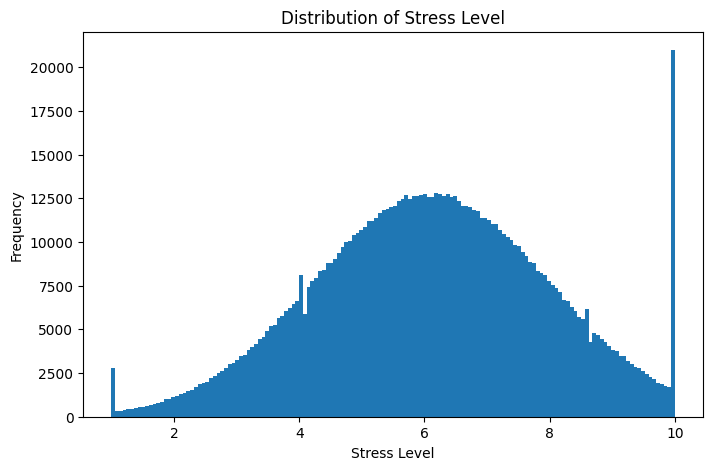

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(df["stress_level"], bins=150)

plt.title("Distribution of Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Frequency")

plt.show()

## Interpretation of Stress Level Distribution

The distribution of `stress_level` is centered around 6, which indicates that most individuals in the dataset have a medium-to-high stress level.

The values range from 1 to 10, confirming that stress level is represented as a bounded numerical variable.

A noticeable peak appears at the maximum value of 10. This may indicate that some high stress values are concentrated at the upper limit of the scale.

Overall, this distribution supports the use of `stress_level` as a regression target. Later, the same variable can also be converted into categorical classes for classification.

# Step 4: Correlation Analysis

In this step, we examine the relationships between numerical features and the target variable `stress_level`.

Correlation analysis helps us identify which numerical variables are more strongly related to stress level.

This is useful before model training because it gives an initial idea about potentially important predictors.

In [26]:
correlation_matrix = df.corr(numeric_only=True)

stress_correlation = correlation_matrix["stress_level"].sort_values(ascending=False)

stress_correlation

stress_level          1.000000
consistency_score     0.122850
heart_rate_resting    0.001760
bmi                   0.001692
hydration_liters      0.001545
diet_quality          0.001338
heart_rate_avg        0.000398
age                   0.000249
sedentary_minutes     0.000219
active_minutes       -0.000040
workouts_per_week    -0.000499
steps_per_day        -0.001299
sleep_hours          -0.368794
sleep_quality        -0.596110
calories_burned            NaN
Name: stress_level, dtype: float64

## Interpretation of Correlation Analysis

The correlation analysis shows that `sleep_quality` has the strongest relationship with `stress_level`. The correlation value is approximately -0.596, which indicates a moderate negative relationship. This means that higher sleep quality is generally associated with lower stress levels.

`sleep_hours` also has a negative correlation with `stress_level`, with a value of approximately -0.369. This suggests that individuals with longer sleep duration tend to have lower stress levels.

`consistency_score` has a weak positive correlation with `stress_level`, with a value of approximately 0.123. However, this relationship is much weaker compared to sleep-related features.

Most of the other numerical features have correlation values close to zero, meaning that they do not show a strong linear relationship with stress level.

The `calories_burned` column has a NaN correlation value because it has the same value for all rows. Since this column has only one unique value, it does not provide useful information for prediction and should be removed during preprocessing.

In [27]:
df["calories_burned"].describe()

count    1000000.0
mean        1500.0
std            0.0
min         1500.0
25%         1500.0
50%         1500.0
75%         1500.0
max         1500.0
Name: calories_burned, dtype: float64

In [28]:
df["calories_burned"].nunique()

1

## Constant Feature Check

The `calories_burned` column contains only one unique value, which is 1500.0.

Since this feature is constant across all rows, it cannot help the model distinguish between different stress levels.

Therefore, this column will be removed during the preprocessing step before model training.

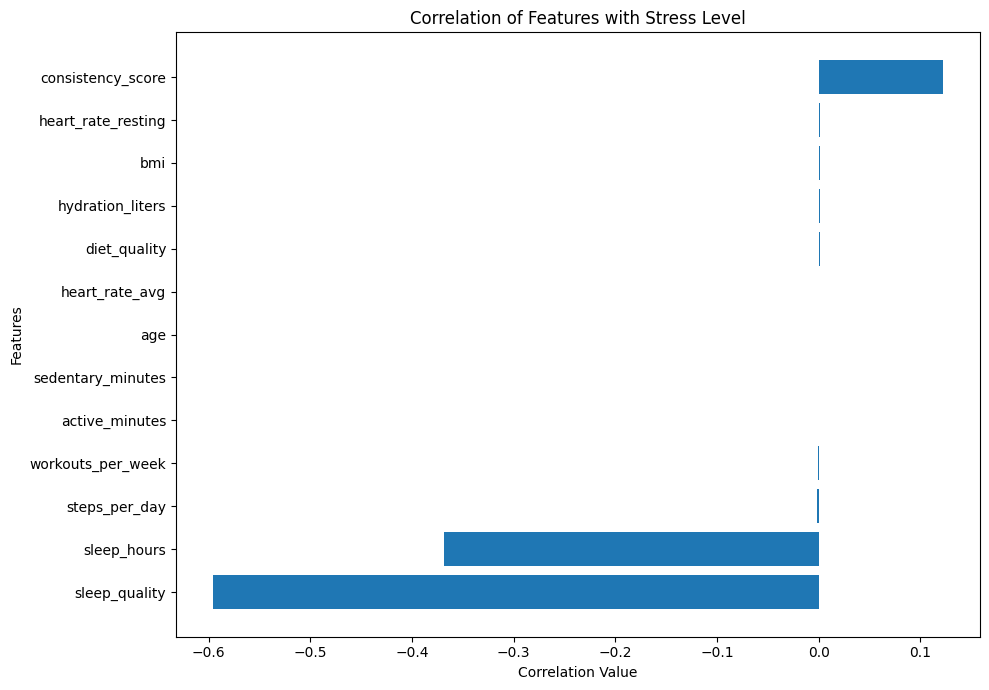

In [29]:
stress_correlation_plot = stress_correlation.drop(labels=["stress_level", "calories_burned"])

stress_correlation_plot = stress_correlation_plot.sort_values()

plt.figure(figsize=(10, 7))

plt.barh(stress_correlation_plot.index, stress_correlation_plot.values)

plt.title("Correlation of Features with Stress Level")
plt.xlabel("Correlation Value")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

## Interpretation of Correlation Bar Chart

The correlation bar chart shows the relationship between each numerical feature and the target variable `stress_level`.

The strongest negative correlation belongs to `sleep_quality`, with a correlation value of approximately -0.596. This indicates that higher sleep quality is generally associated with lower stress levels.

`sleep_hours` also shows a negative correlation with stress level, with a value of approximately -0.369. This suggests that sleep duration is also related to stress level.

`consistency_score` has a weak positive correlation with stress level, while most of the remaining numerical features have correlation values close to zero.

Overall, the correlation analysis suggests that sleep-related features may be important predictors for stress level prediction.

# Step 5: Categorical Feature Analysis

In this step, we analyze the categorical features in the dataset.

The dataset contains two categorical columns: `lifestyle_category` and `fitness_level`.

Before model training, these categorical variables will need to be converted into numerical format. However, in this step, we first examine their distributions.

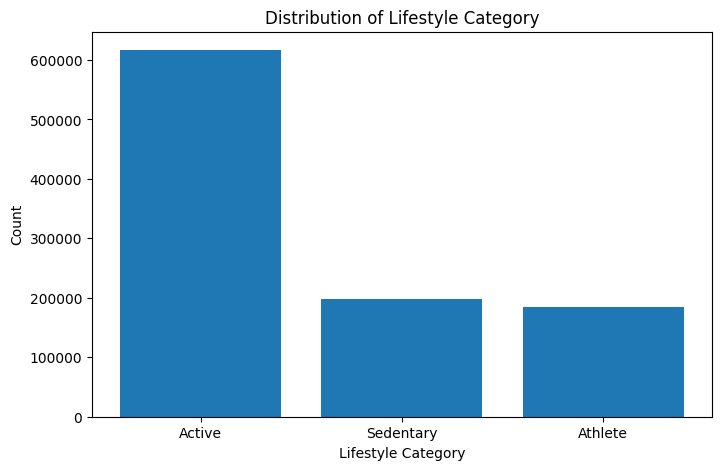

In [30]:
lifestyle_counts = df["lifestyle_category"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(lifestyle_counts.index, lifestyle_counts.values)

plt.title("Distribution of Lifestyle Category")
plt.xlabel("Lifestyle Category")
plt.ylabel("Count")

plt.show()

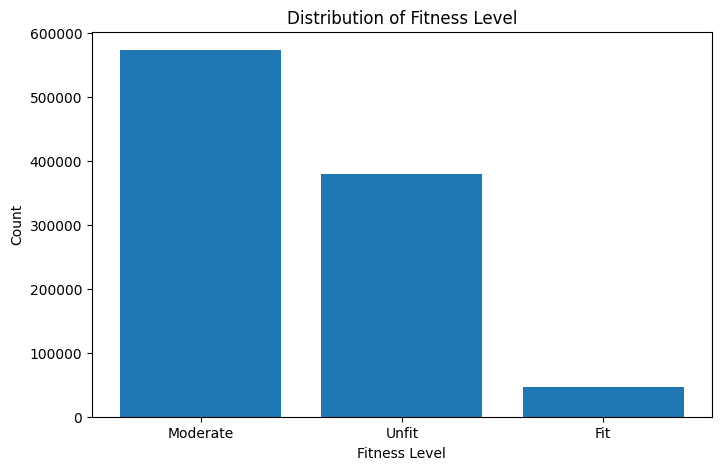

In [31]:
fitness_counts = df["fitness_level"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(fitness_counts.index, fitness_counts.values)

plt.title("Distribution of Fitness Level")
plt.xlabel("Fitness Level")
plt.ylabel("Count")

plt.show()

## Interpretation of Categorical Feature Distributions

The `lifestyle_category` feature contains three groups: Active, Sedentary, and Athlete. The largest group is Active, while Sedentary and Athlete have fewer records.

The `fitness_level` feature also contains three groups: Moderate, Unfit, and Fit. The largest group is Moderate, followed by Unfit. The Fit group has the smallest number of records.

These categorical features may provide useful information for predicting stress level. However, before model training, they need to be converted into numerical format using encoding techniques.

## Average Stress Level by Categorical Features

In this part, we calculate the average stress level for each category in `lifestyle_category` and `fitness_level`.

This helps us understand whether different lifestyle or fitness groups have different average stress levels.

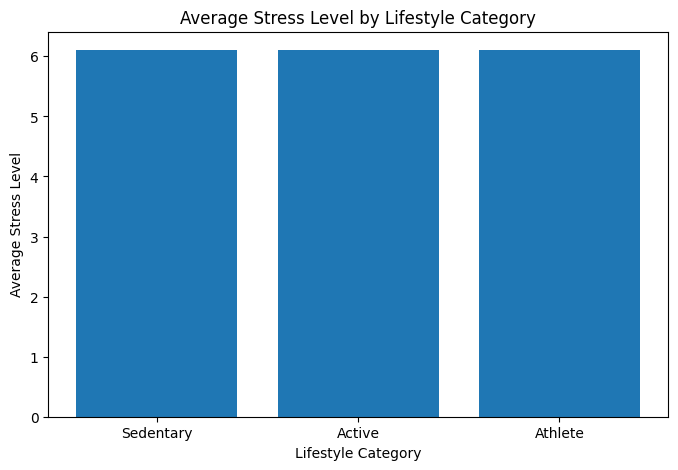

In [33]:
avg_stress_by_lifestyle = df.groupby("lifestyle_category")["stress_level"].mean().sort_values(ascending=False)

avg_stress_by_lifestyle

plt.figure(figsize=(8, 5))

plt.bar(avg_stress_by_lifestyle.index, avg_stress_by_lifestyle.values)

plt.title("Average Stress Level by Lifestyle Category")
plt.xlabel("Lifestyle Category")
plt.ylabel("Average Stress Level")

plt.show()

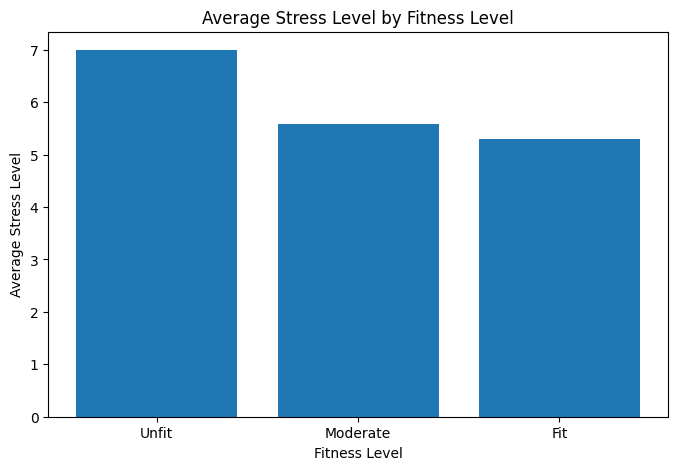

In [36]:
avg_stress_by_fitness = df.groupby("fitness_level")["stress_level"].mean().sort_values(ascending=False)

avg_stress_by_fitness

plt.figure(figsize=(8, 5))

plt.bar(avg_stress_by_fitness.index, avg_stress_by_fitness.values)

plt.title("Average Stress Level by Fitness Level")
plt.xlabel("Fitness Level")
plt.ylabel("Average Stress Level")

plt.show()

## Interpretation of Average Stress Level by Categorical Features

The average stress level is very similar across the `lifestyle_category` groups. Sedentary, Active, and Athlete categories all have an average stress level around 6.1. This suggests that `lifestyle_category` alone may not strongly separate stress levels in this dataset.

However, the `fitness_level` feature shows a clearer difference. The Unfit group has the highest average stress level, while the Fit group has the lowest average stress level. This suggests that `fitness_level` may be more informative than `lifestyle_category` for predicting stress level.

This result does not prove a cause-and-effect relationship, but it shows that fitness level is associated with different average stress levels in the dataset.

# Step 6: Key Numerical Feature Analysis

In this step, we visualize the relationship between important numerical features and the target variable `stress_level`.

Based on the correlation analysis, `sleep_quality`, `sleep_hours`, and `consistency_score` appear to be the most relevant numerical features.

Since the dataset has 1,000,000 rows, we use a random sample of 50,000 rows for scatter plots to make the visualizations faster and easier to read.

In [37]:
df_sample = df.sample(n=50000, random_state=42)

df_sample.shape

(50000, 17)

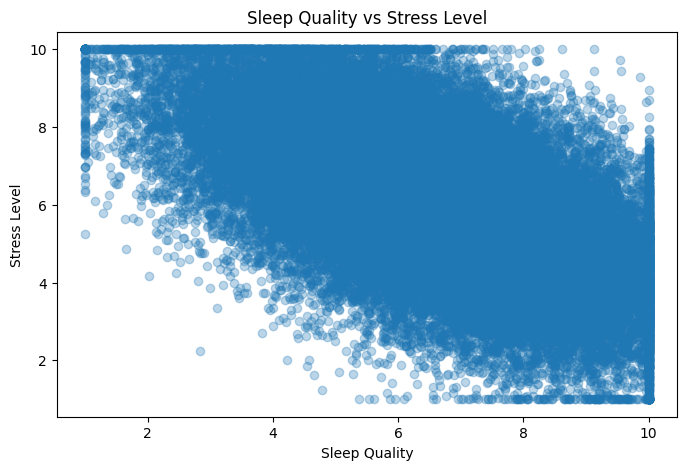

In [38]:
plt.figure(figsize=(8, 5))

plt.scatter(df_sample["sleep_quality"], df_sample["stress_level"], alpha=0.3)

plt.title("Sleep Quality vs Stress Level")
plt.xlabel("Sleep Quality")
plt.ylabel("Stress Level")

plt.show()

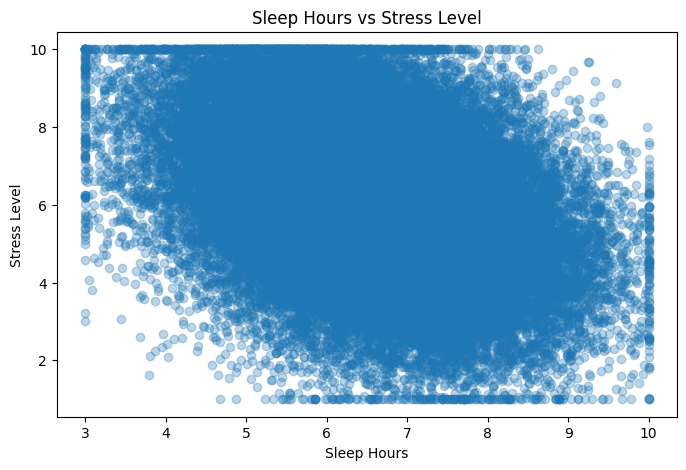

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(df_sample["sleep_hours"], df_sample["stress_level"], alpha=0.3)

plt.title("Sleep Hours vs Stress Level")
plt.xlabel("Sleep Hours")
plt.ylabel("Stress Level")

plt.show()

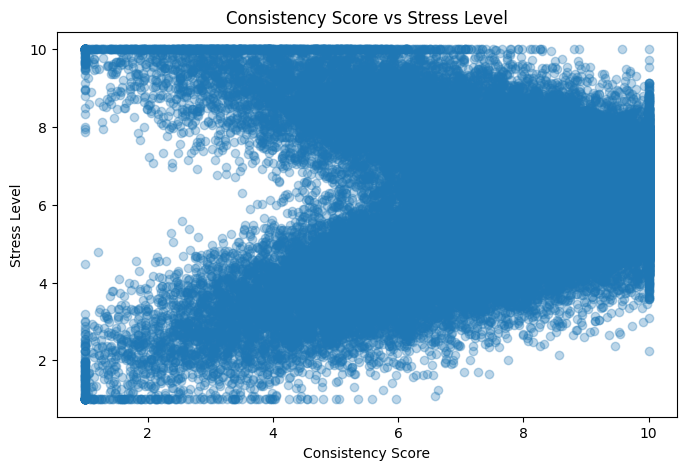

In [40]:
plt.figure(figsize=(8, 5))

plt.scatter(df_sample["consistency_score"], df_sample["stress_level"], alpha=0.3)

plt.title("Consistency Score vs Stress Level")
plt.xlabel("Consistency Score")
plt.ylabel("Stress Level")

plt.show()

## Interpretation of Key Numerical Feature Relationships

The scatter plot between `sleep_quality` and `stress_level` shows a clear negative relationship. As sleep quality increases, stress level generally tends to decrease. This supports the correlation result, where `sleep_quality` had the strongest negative correlation with stress level.

The relationship between `sleep_hours` and `stress_level` is also negative, but it appears weaker compared to sleep quality. Higher sleep duration is generally associated with lower stress levels, although the points are more widely spread.

The `consistency_score` plot shows a weaker and less direct relationship with stress level. Although the correlation analysis showed a small positive correlation, the scatter plot indicates that this relationship is not as clear as the sleep-related features.

Overall, these visualizations suggest that sleep-related variables, especially `sleep_quality`, may be important predictors for stress level prediction.

# Step 7: Exploratory Data Analysis Summary

In this notebook, the Health Indicators dataset was loaded and explored.

The dataset contains 1,000,000 rows and 17 columns. No missing values or duplicate rows were found, which shows that the dataset is already clean and well-structured.

The target variable of the project is `stress_level`, which ranges from 1 to 10. The average stress level is approximately 6.10, indicating that the values are mostly centered around the medium-to-high stress range.

Correlation analysis showed that `sleep_quality` and `sleep_hours` have the strongest negative relationships with `stress_level`. This means that higher sleep quality and longer sleep duration are generally associated with lower stress levels.

The `calories_burned` column was found to have only one unique value, so it does not provide useful information for prediction and should be removed during preprocessing.

The categorical features `lifestyle_category` and `fitness_level` were also analyzed. `fitness_level` showed clearer differences in average stress level compared to `lifestyle_category`.

Based on this exploratory analysis, the next step is preprocessing. In the preprocessing step, categorical variables will be encoded, the constant `calories_burned` column will be removed, and the dataset will be prepared for regression and classification models.